# (노트) Pytorch Linear Regression - 방법2

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

### Import 

In [298]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

### graphviz 

In [296]:
import graphviz

`-` graphviz가 설치안되어 있다면 아래와 같은 방법으로 설치하라. (반드시 콘다로 설치해야함. pip로 설치하면 path를 따로 설정해줘야하더라) 
```
!conda install -c conda-forge graphviz -y 
```

`-` 아래와 같이 하면 다이어그램을 쉽게 쓸 수 있다. 

In [295]:
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"' + s + '; }')

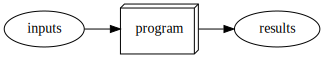

In [294]:
gv('''program[shape=box3d width=1 height=0.7]
inputs->program->results''')

### Data (Pytorch Linear Regression 방법1과 동일한데이터 사용) 

`-` model: $y_i=w_0+w_1x_i+\epsilon_i=2.5+4x_i+\epsilon_i , \quad i=1,2,\dots,n $ 

`-` model: ${\bf y} = {\bf X} {\bf W} +\boldsymbol{\epsilon}$ 
 - ${\bf y}=\begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n\end{bmatrix}, \quad  {\bf X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ .. \\ 1 & x_n \end{bmatrix}, \quad {\bf W}= \begin{bmatrix} 2.5 \\ 4 \end{bmatrix} $ 

In [272]:
torch.manual_seed(43052)
n = 100 
ones = torch.ones(n)
x,_ = torch.randn(n).sort()
X = torch.vstack([ones,x]).T
W = torch.tensor([2.5,4]) 
ϵ = torch.randn(n)*0.5

In [273]:
y=X@W+ϵ
ytrue=X@W

- ${\bf y}={\bf X W}+\boldsymbol{\epsilon}$ 
- ${\bf y}_{\tt ture}={\bf X W}$ 

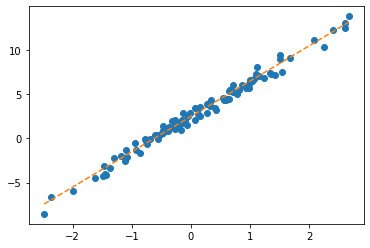

In [274]:
plt.plot(x,y,'o')
plt.plot(x,ytrue,'--')

### ($\star$)주의: 파이썬에서 벡터는 기본적으로 row-vector이다. 

### 이전방법요약 

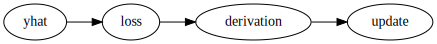

In [275]:
gv('''yhat -> loss -> derivation -> update''')

### modeling 

`-` feedforward 신경망을 설계함 

`-` 이 단계가 끝났다면, 아래와 같은 임의의 $\bf{\hat{W}}$을 넣었을때 ${\bf\hat{y}}$를 계산할 수 있어야 함. 

In [276]:
What = torch.tensor([-5.0,10.0],requires_grad=True)

#### 방법1: 직접선언 (내가 공식을 알고 있을때) 

In [277]:
yhat1 = X@What
yhat1

tensor([-29.8211, -28.6215, -24.9730, -21.2394, -19.7919, -19.6354, -19.5093,
        -19.4352, -18.7223, -18.0793, -16.9040, -16.0918, -16.0536, -15.8746,
        -14.4690, -14.3193, -13.6426, -12.8578, -12.5486, -12.4213, -11.9484,
        -11.1034, -10.8296, -10.6210, -10.5064, -10.0578,  -9.8063,  -9.7380,
         -9.7097,  -9.6756,  -8.8736,  -8.7195,  -8.6880,  -8.1592,  -7.7752,
         -7.7716,  -7.7339,  -7.7208,  -7.6677,  -7.1551,  -7.0004,  -6.8163,
         -6.7081,  -6.5655,  -6.4480,  -6.3612,  -6.0566,  -5.6031,  -5.5589,
         -5.2137,  -4.3446,  -4.3165,  -3.8047,  -3.5801,  -3.4793,  -3.4325,
         -2.3545,  -2.3440,  -1.8434,  -1.7799,  -1.5386,  -1.0161,  -0.8103,
          0.4426,   0.5794,   0.9125,   1.1483,   1.4687,   1.4690,   1.5234,
          1.6738,   2.0592,   2.1414,   2.8221,   3.1536,   3.6682,   4.2907,
          4.8037,   4.8531,   4.9414,   5.3757,   5.3926,   5.6973,   6.0239,
          6.1261,   6.5317,   7.2891,   8.4032,   8.4936,   9.27

#### 방법2: torch.nn.Linear() 사용

In [284]:
net1 = torch.nn.Linear(in_features=2,out_features=1,bias=False)

In [285]:
net1.weight

Parameter containing:
tensor([[ 0.5485, -0.1228]], requires_grad=True)

In [286]:
net1.weight.data=torch.tensor([-5.0,10.0])
net1.weight

Parameter containing:
tensor([-5., 10.], requires_grad=True)

In [287]:
net1(X)

tensor([-29.8211, -28.6215, -24.9730, -21.2394, -19.7919, -19.6354, -19.5093,
        -19.4352, -18.7223, -18.0793, -16.9040, -16.0918, -16.0536, -15.8746,
        -14.4690, -14.3193, -13.6426, -12.8578, -12.5486, -12.4213, -11.9484,
        -11.1034, -10.8296, -10.6210, -10.5064, -10.0578,  -9.8063,  -9.7380,
         -9.7097,  -9.6756,  -8.8736,  -8.7195,  -8.6880,  -8.1592,  -7.7752,
         -7.7716,  -7.7339,  -7.7208,  -7.6677,  -7.1551,  -7.0004,  -6.8163,
         -6.7081,  -6.5655,  -6.4480,  -6.3612,  -6.0566,  -5.6031,  -5.5589,
         -5.2137,  -4.3446,  -4.3165,  -3.8047,  -3.5801,  -3.4793,  -3.4325,
         -2.3545,  -2.3440,  -1.8434,  -1.7799,  -1.5386,  -1.0161,  -0.8103,
          0.4426,   0.5794,   0.9125,   1.1483,   1.4687,   1.4690,   1.5234,
          1.6738,   2.0592,   2.1414,   2.8221,   3.1536,   3.6682,   4.2907,
          4.8037,   4.8531,   4.9414,   5.3757,   5.3926,   5.6973,   6.0239,
          6.1261,   6.5317,   7.2891,   8.4032,   8.4936,   9.27

In [288]:
net2 = torch.nn.Linear(in_features=1,out_features=1,bias=True)

In [248]:
net2.bias

Parameter containing:
tensor([0.8287], requires_grad=True)

In [249]:
net2.bias.data=torch.tensor([-5.0])

In [250]:
net2.bias

Parameter containing:
tensor([-5.], requires_grad=True)

In [251]:
net2.weight

Parameter containing:
tensor([[-0.2615]], requires_grad=True)

In [252]:
net2.weight.data=torch.tensor([[10.0]])

In [253]:
net2.weight

Parameter containing:
tensor([[10.]], requires_grad=True)

In [254]:
net2(x.reshape(100,1)).flatten()

tensor([-29.8211, -28.6215, -24.9730, -21.2394, -19.7919, -19.6354, -19.5093,
        -19.4352, -18.7223, -18.0793, -16.9040, -16.0918, -16.0536, -15.8746,
        -14.4690, -14.3193, -13.6426, -12.8578, -12.5486, -12.4213, -11.9484,
        -11.1034, -10.8296, -10.6210, -10.5064, -10.0578,  -9.8063,  -9.7380,
         -9.7097,  -9.6756,  -8.8736,  -8.7195,  -8.6880,  -8.1592,  -7.7752,
         -7.7716,  -7.7339,  -7.7208,  -7.6677,  -7.1551,  -7.0004,  -6.8163,
         -6.7081,  -6.5655,  -6.4480,  -6.3612,  -6.0566,  -5.6031,  -5.5589,
         -5.2137,  -4.3446,  -4.3165,  -3.8047,  -3.5801,  -3.4793,  -3.4325,
         -2.3545,  -2.3440,  -1.8434,  -1.7799,  -1.5386,  -1.0161,  -0.8103,
          0.4426,   0.5794,   0.9125,   1.1483,   1.4687,   1.4690,   1.5234,
          1.6738,   2.0592,   2.1414,   2.8221,   3.1536,   3.6682,   4.2907,
          4.8037,   4.8531,   4.9414,   5.3757,   5.3926,   5.6973,   6.0239,
          6.1261,   6.5317,   7.2891,   8.4032,   8.4936,   9.27

### define loss

#### 방법1: 직접선언

In [75]:
loss1=torch.mean((y-yhat)**2)  ## sum으로 해도 괜찮지만 mean으로 하자.. 

#### 방법2: torch.nn.MSEloss()를 이용

In [92]:
lossfn=torch.nn.MSELoss() # loss function instance 만듬
loss2=lossfn(yhat1,y)

In [93]:
loss1,loss2

(tensor(85.8769, grad_fn=<MeanBackward0>),
 tensor(85.8769, grad_fn=<MseLossBackward>))

- 미분꼬리표가 약간다르다. (신경안써도 무방한듯)

### update parameter

In [47]:
learning_rate=0.1

In [48]:
losses=[]

In [51]:
What.grad = None
yhat=torch.mv(X,What)
loss=torch.mean((y-yhat)**2)
loss.backward()

In [53]:
What,What.data

(tensor([-0.3554,  0.1147,  0.1921], requires_grad=True),
 tensor([-0.3554,  0.1147,  0.1921]))

In [56]:
What.grad.data

tensor([ -2.2220,   4.9197, -10.8512])

In [55]:
What.data=What.data - learning_rate * What.grad.data

In [57]:
losses.append(loss.item())

In [58]:
losses

[32.722450256347656]